# Data Visualization & Topic Modeling

## Context
Before diving into topic modeling, we first explore the dataset visually.
This helps us understand the distribution of reviews, the most active insurers,
and the general sentiment of customers. These insights will guide our topic
modeling choices and help us interpret the results.

## In this notebook we will:
- Visualize the dataset (ratings, insurers, time, word cloud, review length)
- Apply Topic Modeling using LDA to detect main themes in the reviews
- Assign a topic to each review
- Interpret and present the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import nltk
import warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")
stop_fr = set(stopwords.words("french"))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dovila/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("cleaned_dataset.csv")
df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce')

print(f"Shape: {df.shape}")
df.head()

Shape: (34428, 11)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_clean,avis_cor
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,2021-10-06,2021-10-01,The person on the phone was clear and friendly...,la personne au téléphone était clair et sympat...,la personne au téléphone était clair et sympat...
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,2021-07-09,2021-07-01,"Satisfied.\n\nReactivity, simplicity. Attracti...",satisfait réactivité simplicité prix attractif...,satisfait réactivité simplicité prix attractif...
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,2020-10-15,2020-10-01,"Insurer to flee, does not ensure its responsib...",assureur à fuir n assure pas ses responsabilit...,assureur à fuir un assure pas ses responsabili...
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,2020-03-03,2020-03-01,The GMF has been waiting for a water damage fo...,voilà mois que la gmf me fait attendre pour un...,voilà mois que la me me fait attendre pour un ...
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,2021-08-28,2021-08-01,I am good with this insurance. She is practica...,je suis bien avec cet assurance elle est prati...,je suis bien avec cet assurance elle est prati...


### Part 1 — Data Visualization
In this section we explore the dataset visually to understand the distribution
of reviews, the most active insurers, and the evolution of ratings over time.

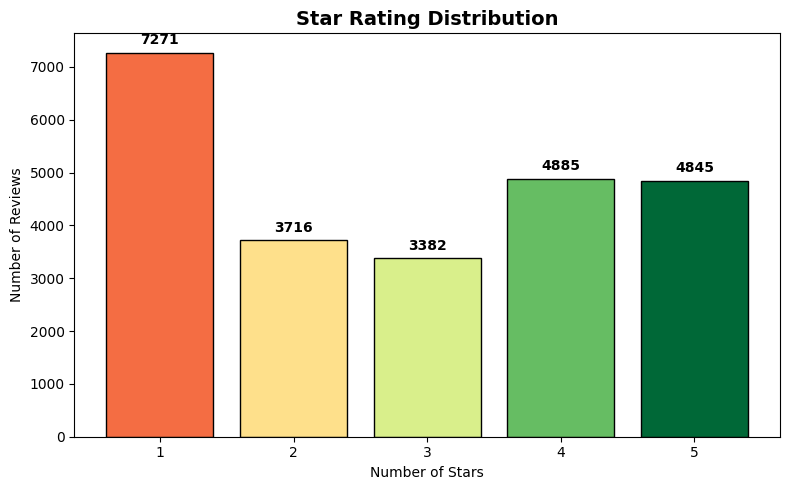

Average rating: 2.85 / 5
note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4845
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(8, 5))
rating_counts = df['note'].dropna().value_counts().sort_index()
colors = cm.RdYlGn([x/5 for x in rating_counts.index])
bars = plt.bar(rating_counts.index.astype(int), rating_counts.values, color=colors, edgecolor='black')
for bar, count in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.title("Star Rating Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Stars")
plt.ylabel("Number of Reviews")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

print(f"Average rating: {df['note'].mean():.2f} / 5")
print(df['note'].value_counts().sort_index())

The rating distribution reveals a clear polarization in customer reviews.
1-star reviews are by far the most common (7,271), suggesting that dissatisfied
customers are more likely to leave a review than satisfied ones. The average
rating of 2.85/5 is relatively low, reflecting an overall negative sentiment
in the dataset. This class imbalance will need to be addressed during our
supervised learning phase to avoid biased models.

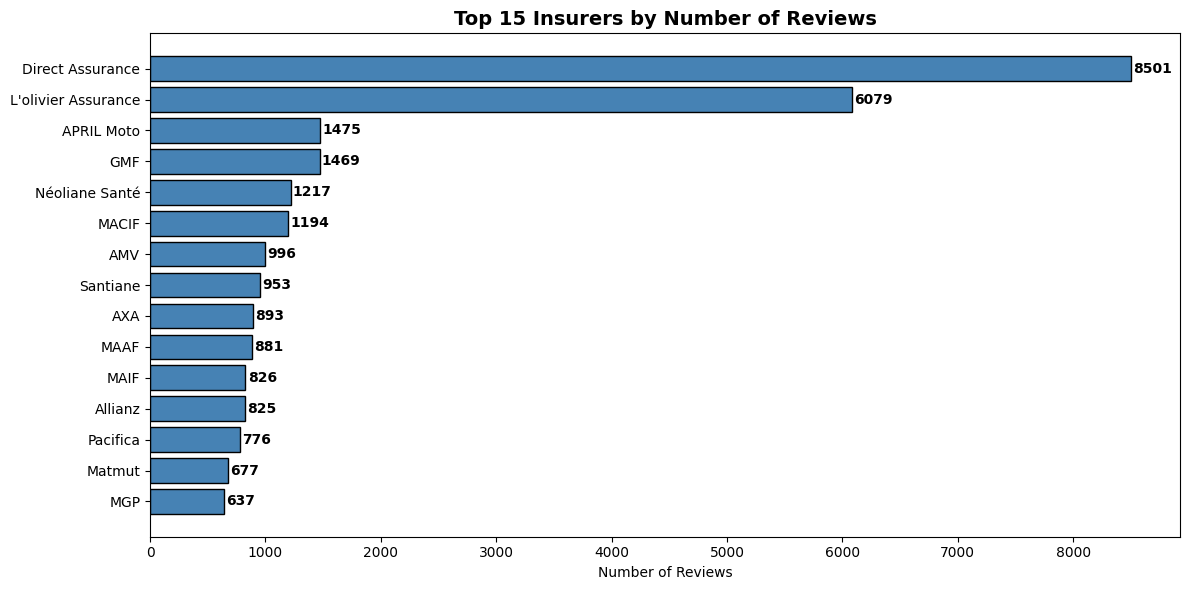

In [4]:
top_insurers = df['assureur'].value_counts().head(15)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_insurers.index[::-1], top_insurers.values[::-1], color='steelblue', edgecolor='black')
for bar, count in zip(bars, top_insurers.values[::-1]):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontweight='bold')
plt.title("Top 15 Insurers by Number of Reviews", fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews")
plt.tight_layout()
plt.show()

The chart reveals a highly uneven distribution of reviews across insurers.
**Direct Assurance** dominates with 8,501 reviews, followed by **L'olivier Assurance**
with 6,079 and together they represent nearly half of the entire dataset. The remaining
insurers have significantly fewer reviews (under 1,500 each). This means our models
will naturally know these two insurers much better than the others, which could
introduce bias in insurer-level analysis. This is something to keep in mind when
building our Streamlit insurer analysis application.

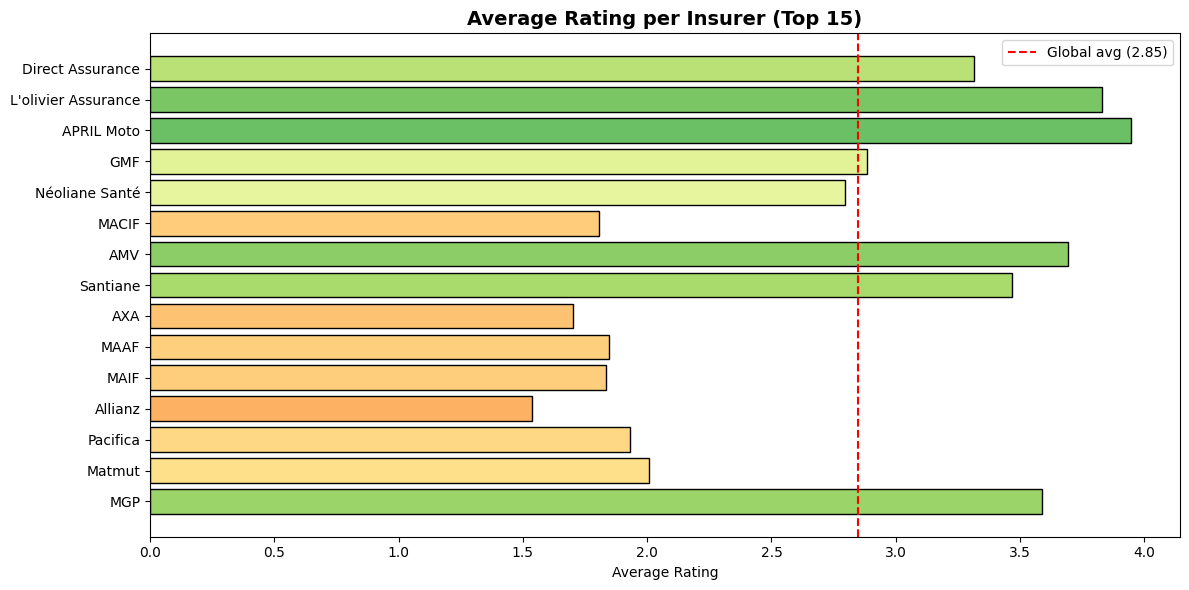

In [5]:
avg_rating = df.groupby('assureur')['note'].mean().dropna()
top_avg = avg_rating.loc[top_insurers.index]

plt.figure(figsize=(12, 6))
colors = cm.RdYlGn([r/5 for r in top_avg.values[::-1]])
plt.barh(top_avg.index[::-1], top_avg.values[::-1], color=colors, edgecolor='black')
plt.axvline(x=df['note'].mean(), color='red', linestyle='--', label=f"Global avg ({df['note'].mean():.2f})")
plt.title("Average Rating per Insurer (Top 15)", fontsize=14, fontweight='bold')
plt.xlabel("Average Rating")
plt.legend()
plt.tight_layout()
plt.show()

The average rating per insurer reveals significant differences in customer satisfaction.
**APRIL Moto** stands out as the best rated insurer (4.0/5), followed by **L'olivier
Assurance** and **AMV**. On the other hand, **Allianz** and **AXA** have the lowest
average ratings (below 2.0/5), indicating high customer dissatisfaction.

**Direct Assurance** , the most reviewed insurer  sits just above the
global average (2.85), suggesting a mixed customer experience. Most insurers fall
**below** the global average, which confirms the overall negative sentiment we observed
in the rating distribution. This will be a useful reference when building our
insurer analysis Streamlit application.

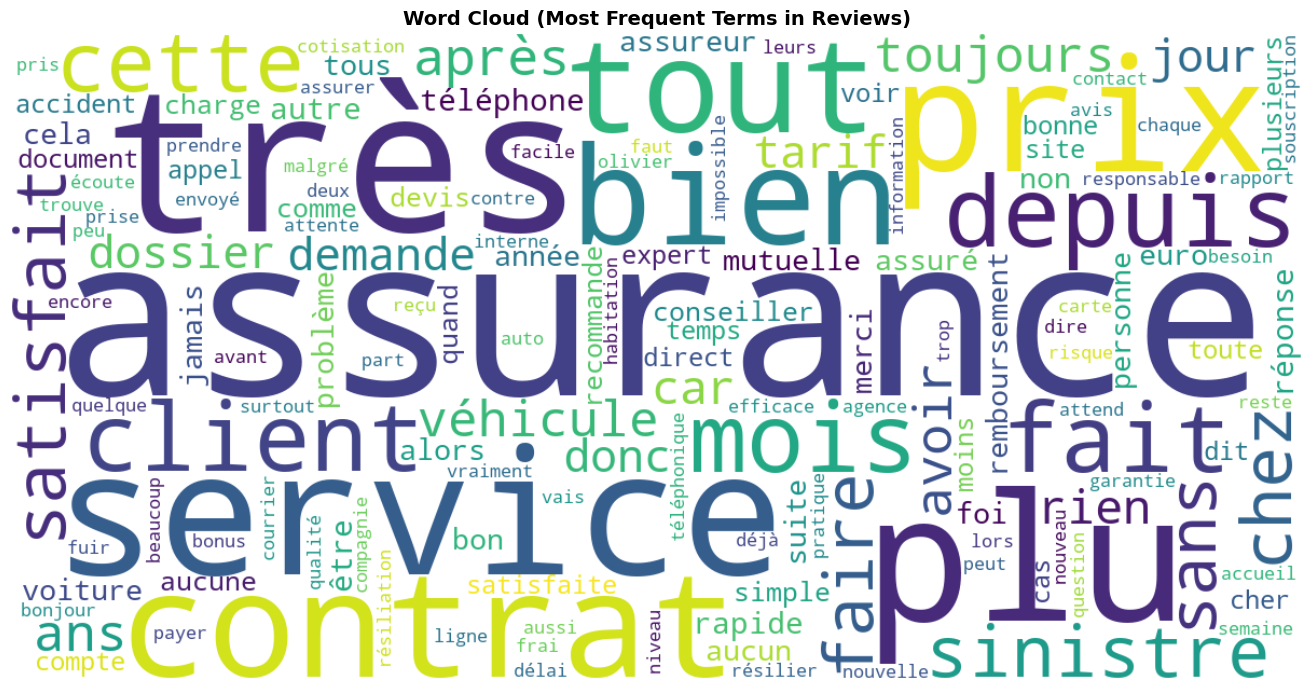

In [7]:
text_corpus = " ".join(df['avis_cor'].dropna().astype(str))

clean_corpus = " ".join([
    w for w in text_corpus.split()
    if w not in stop_fr and len(w) > 2
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(clean_corpus)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (Most Frequent Terms in Reviews)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

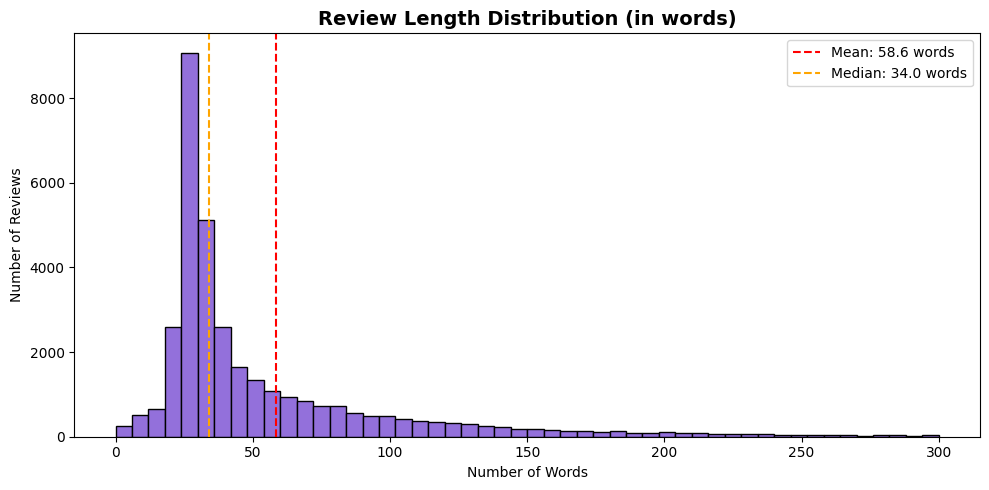

Average review length : 58.6 words
Median review length  : 34.0 words
Max review length     : 1469 words
Min review length     : 1 words


In [8]:
df['review_length'] = df['avis'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(df['review_length'], bins=50, color='mediumpurple', edgecolor='black', range=(0, 300))
plt.axvline(df['review_length'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['review_length'].mean():.1f} words")
plt.axvline(df['review_length'].median(), color='orange', linestyle='--',
            label=f"Median: {df['review_length'].median():.1f} words")
plt.title("Review Length Distribution (in words)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average review length : {df['review_length'].mean():.1f} words")
print(f"Median review length  : {df['review_length'].median():.1f} words")
print(f"Max review length     : {df['review_length'].max()} words")
print(f"Min review length     : {df['review_length'].min()} words")

Here most reviews are  short while a few are very long. The median of 34 words is much lower
than the mean of 58.6 words, confirming the presence of outlier reviews that are
unusually long (up to 1,469 words). Most customers write brief reviews, which is
typical for online feedback platforms.

This is important for our supervised learning models:
- Models like **TF-IDF** handle variable length well
- Models like **BERT** have a maximum input of 512 tokens, so very long reviews
  will need to be truncated
- Very short reviews (1-5 words) may not carry enough information for our models
  to learn from effectively

## Part 2 — Topic Modeling
Topic modeling is an unsupervised NLP technique that automatically discovers
hidden themes in a collection of texts. We use **LDA (Latent Dirichlet
Allocation)**, which assumes each document is a mixture of topics and each
topic is a mixture of words. Applied to our insurance reviews, it will help
us identify the main subjects customers talk about such as pricing, claims,
and customer service  without any human supervision.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# Use cor French reviews for topic modeling
texts = df['avis_cor'].dropna().astype(str).tolist()

# Vectorize the text
vectorizer = CountVectorizer(
    max_df=0.95,        # ignore words that appear in 95%+ of documents
    min_df=5,           # ignore words that appear in less than 5 documents
    stop_words=list(stop_fr),
    max_features=5000
)

X = vectorizer.fit_transform(texts)
print(f"Vocabulary size: {X.shape[1]}")
print(f"Number of documents: {X.shape[0]}")

Vocabulary size: 5000
Number of documents: 34427


In [10]:
# Train LDA model
n_topics = 6  # number of topics to discover as mentionned in the pdf

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=10,
    learning_method='online'
)

lda.fit(X)
print(f"LDA model trained with {n_topics} topics!")

LDA model trained with 6 topics!


In [12]:
# Display top words per topic
def display_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {' | '.join(top_words)}")

feature_names = vectorizer.get_feature_names_out()
display_topics(lda, feature_names)

Topic 1: assurance | sinistre | ans | plus | véhicule | chez | depuis | voiture | accident | expert
Topic 2: très | prix | service | assurance | satisfait | rapide | bien | merci | recommande | simple
Topic 3: mutuelle | cette | remboursements | très | bien | remboursement | charge | vers | avis | peu
Topic 4: contrat | assurance | plus | année | si | assureur | chez | cette | faire | tout
Topic 5: service | téléphone | demande | avoir | fois | client | personne | dossier | plus | toujours
Topic 6: mois | depuis | plus | toujours | aucune | après | malgré | dossier | sans | cette


In [13]:
topic_labels = {
    0: "Claims Processing",
    1: "Pricing",
    2: "Coverage",
    3: "Enrollment",
    4: "Customer Service",
    5: "Cancellation"
}

# Get the dominant topic for each review
doc_topics = lda.transform(X)
df_lda = df.dropna(subset=['avis_cor']).copy()
df_lda['topic_id'] = doc_topics.argmax(axis=1)
df_lda['topic'] = df_lda['topic_id'].map(topic_labels)

print("Topics assigned!")
df_lda[['avis', 'topic']].head(10)

Topics assigned!


,avis,topic
0,La personne au téléphone était Clair et sympat...,Pricing
1,"Satisfait.\n\nRéactivité, simplicité. Prix att...",Pricing
2,"Assureur à fuir, n assure pas ses responsabili...",Customer Service
3,Voilà 3 mois que la GMF me fait attendre pour ...,Claims Processing
4,Je suis bien avec cet assurance.elle est prati...,Pricing
5,Le drive box nest pas tres fiable.Ca demande b...,Enrollment
6,J'ai malheureusement eu à faire appel à plusie...,Customer Service
7,Suite à mon bris de glace le traitement de cel...,Customer Service
8,"Bonjour , Actuellement je suis chez Active Ass...",Claims Processing
9,Ma mère est décédée depuis plusieurs mois et ...,Customer Service


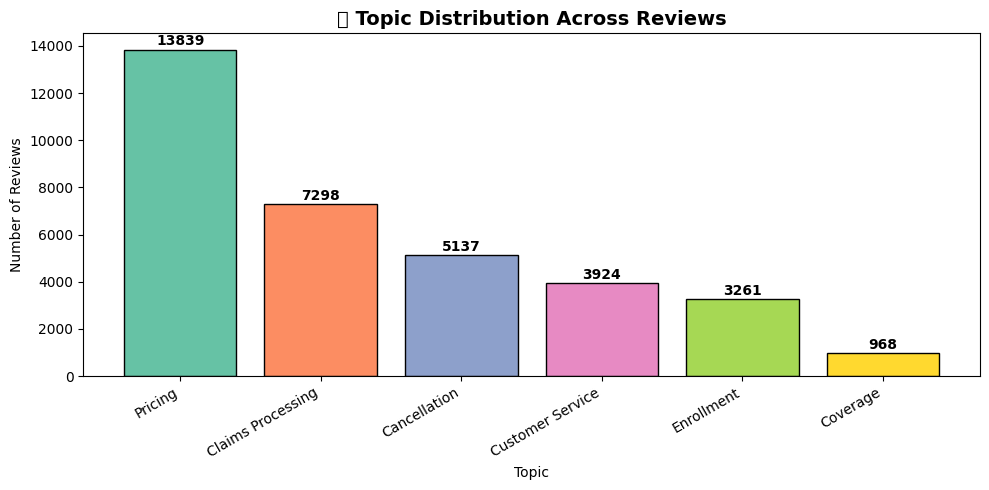

In [14]:
plt.figure(figsize=(10, 5))
topic_counts = df_lda['topic'].value_counts()
colors = plt.cm.Set2(range(len(topic_counts)))
bars = plt.bar(topic_counts.index, topic_counts.values, color=colors, edgecolor='black')
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.title("📊 Topic Distribution Across Reviews", fontsize=14, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Pricing** is by far the most discussed topic (13,839 reviews), confirming that
cost is the primary concern for insurance customers. **Claims Processing** comes
second (7,298), followed by **Cancellation** and **Customer Service**. **Coverage**
is the least discussed topic (968 reviews). This distribution aligns with the low
average rating we observed earlier  customers are most vocal when unhappy with
costs or claim handling.

In [15]:
df_lda.to_csv("topic_dataset.csv", index=False)
print(f"Final shape: {df_lda.shape}")

Final shape: (34427, 15)
